# Лабораторная работа 6

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы (SGD, SGD+Momentum, Adam), и сформулировать свои практические правила выбора.

> Этот ноутбук предназначен именно для вашей самостоятельной работы.  
> Его структура и код — каркас, а содержание (графики, комментарии, выводы) должны отражать **ваши эксперименты и ваш стиль объяснения**.
> Если вы попытаетесь автоматически сгенерировать текст целиком, это будет заметно по общей, оторванной от ваших графиков формулировке.


## 1. Ваши ожидания до экспериментов

Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [4]:
expectations_text = """1) Я думаю, что при маленьком шаге, кривая loss будет медленно уменьшаться, можно сказать, что почти по прямой.
    И, например, вместо 8 эпох, понадобится 16, а это замедлит обучение. 
    К высокой точности, думаю, сможем придти, но процесс сходимсоти будет длительным.

2) ПРи слишком большом шаге, я думаю кривая Loss быстро упадет, а потом начнет колебаться.
    С графиком accuracy, думаю, будет резкое повышение, а потом также колебание графика.
    И в конечном итоге, ни график потерь, ни график точность не придут к стабильному результату, не будет низкой loss и высокой accuracy.

3) Я думаю, что из 3ёх оптимизаторов, самым быстрым окажется Adam(так как мы его уже пробовали).
    Он не так чувствителен к выбору шага, но не стоит выбирать слишком большой или маленький.
    ПРи большом шаге он может расходиться.
    
SGD будет самым медленным. Важно правильно настроить шаг, график loss может быть с колебаниями, сходимость медленная. 

SGD с momentum будет чуть лучше простого SGD, быстрее снижаться график Loss, меньше колебаний.
    Monetum будет ускорять сходимость. 

"""
print(expectations_text)

1) Я думаю, что при маленьком шаге, кривая loss будет медленно уменьшаться, можно сказать, что почти по прямой.
    И, например, вместо 8 эпох, понадобится 16, а это замедлит обучение. 
    К высокой точности, думаю, сможем придти, но процесс сходимсоти будет длительным.

2) ПРи слишком большом шаге, я думаю кривая Loss быстро упадет, а потом начнет колебаться.
    С графиком accuracy, думаю, будет резкое повышение, а потом также колебание графика.
    И в конечном итоге, ни график потерь, ни график точность не придут к стабильному результату, не будет низкой loss и высокой accuracy.

3) Я думаю, что из 3ёх оптимизаторов, самым быстрым окажется Adam(так как мы его уже пробовали).
    Он не так чувствителен к выбору шага, но не стоит выбирать слишком большой или маленький.
    ПРи большом шаге он может расходиться.

SGD будет самым медленным. Важно правильно настроить шаг, график loss может быть с колебаниями, сходимость медленная. 

SGD с momentum будет чуть лучше простого SGD, быстрее

## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [5]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ ЛИЧНЫЙ SEED (можете выбрать любое число, но потом не меняйте его без причины)
MY_SEED = 22
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 22


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


In [21]:
batch_size = 128 # TODO: поменять и прокомментировать выбор в выводах

# В 4лр я выбрала 128, объяснив так:
# Я взяла по своему мнению средний размер батча, но пробовала и более низкие, и более высокие.
# На высоких размерах обучение происходит быстрее, чем на низких. На низких размерах картинки выглядят грязными. 

# После этого я не меняла размер батча
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

train size = 60000
test size  = 10000
batch_size = 128


Если вы хотите для спокойствия посмотреть на пару примеров изображений — можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


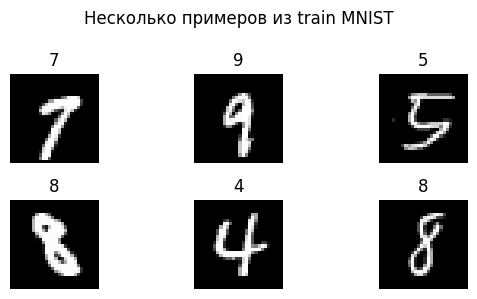

In [22]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените — **обязательно явно зафиксируйте это в отчёте**).


In [23]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [24]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [25]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs,
                   num_epochs=8):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор конфигураций для сравнения

Рекомендуемый набор (можете расширить):

- `SGD lr=0.001` — заведомо небольшой шаг;  
- `SGD lr=0.01` — разумный кандидат;  
- `SGD lr=0.5` — намеренно большой шаг, чтобы увидеть нестабильность;  
- `SGD lr=0.01, momentum=0.9` — добавляем momentum и смотрим, что изменится;  
- `Adam lr=0.001` — «типичная» настройка для Adam.

Число эпох выберите так, чтобы кривые успели чуть-чуть «устаканиться» (например, 8–12 эпох).


In [26]:
num_epochs = 8  # учитывайте время обучения

histories = []
labels = []

# 1. SGD с маленьким шагом
h_sgd_small = run_experiment(
    config_name="SGD lr=0.001",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_sgd_small)
labels.append("SGD 0.001")

# 2. SGD с "разумным" шагом
h_sgd_mid = run_experiment(
    config_name="SGD lr=0.01",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_sgd_mid)
labels.append("SGD 0.01")

# 3. SGD с большим шагом
h_sgd_big = run_experiment(
    config_name="SGD lr=0.5",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_sgd_big)
labels.append("SGD 0.5")

# 4. SGD с momentum
h_sgdm = run_experiment(
    config_name="SGD lr=0.01, momentum=0.9",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01, "momentum": 0.9},
    num_epochs=num_epochs
)
histories.append(h_sgdm)
labels.append("SGD+mom 0.01")

# 5. Adam
h_adam = run_experiment(
    config_name="Adam lr=0.001",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.001")

# 6. TODO: предложите свой вариант
# Adam с намеренно большим шагом
h_adam = run_experiment(
    config_name="Adam lr=0.01",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.01")


=== Конфигурация: SGD lr=0.001 ===
Эпоха 1/8 | train_loss=2.2403, train_acc=0.2461, test_loss=2.1614, test_acc=0.5119
Эпоха 2/8 | train_loss=2.0622, train_acc=0.6147, test_loss=1.9237, test_acc=0.7010
Эпоха 3/8 | train_loss=1.7597, train_acc=0.7292, test_loss=1.5449, test_acc=0.7690
Эпоха 4/8 | train_loss=1.3590, train_acc=0.7763, test_loss=1.1420, test_acc=0.7985
Эпоха 5/8 | train_loss=1.0167, train_acc=0.8063, test_loss=0.8652, test_acc=0.8239
Эпоха 6/8 | train_loss=0.8018, train_acc=0.8287, test_loss=0.7045, test_acc=0.8450
Эпоха 7/8 | train_loss=0.6741, train_acc=0.8444, test_loss=0.6061, test_acc=0.8557
Эпоха 8/8 | train_loss=0.5929, train_acc=0.8559, test_loss=0.5413, test_acc=0.8651

=== Конфигурация: SGD lr=0.01 ===
Эпоха 1/8 | train_loss=1.1970, train_acc=0.7169, test_loss=0.4747, test_acc=0.8778
Эпоха 2/8 | train_loss=0.4038, train_acc=0.8876, test_loss=0.3373, test_acc=0.9062
Эпоха 3/8 | train_loss=0.3241, train_acc=0.9069, test_loss=0.2921, test_acc=0.9178
Эпоха 4/8 | trai

In [ ]:
# ДЛЯ СЕБЯ
# === Конфигурация: SGD lr=0.001 ===
# Эпоха 1/8 | train_loss=2.2403, train_acc=0.2461, test_loss=2.1614, test_acc=0.5119
# Эпоха 2/8 | train_loss=2.0622, train_acc=0.6147, test_loss=1.9237, test_acc=0.7010
# Эпоха 3/8 | train_loss=1.7597, train_acc=0.7292, test_loss=1.5449, test_acc=0.7690
# Эпоха 4/8 | train_loss=1.3590, train_acc=0.7763, test_loss=1.1420, test_acc=0.7985
# Эпоха 5/8 | train_loss=1.0167, train_acc=0.8063, test_loss=0.8652, test_acc=0.8239
# Эпоха 6/8 | train_loss=0.8018, train_acc=0.8287, test_loss=0.7045, test_acc=0.8450
# Эпоха 7/8 | train_loss=0.6741, train_acc=0.8444, test_loss=0.6061, test_acc=0.8557
# Эпоха 8/8 | train_loss=0.5929, train_acc=0.8559, test_loss=0.5413, test_acc=0.8651

# === Конфигурация: SGD lr=0.01 ===
# Эпоха 1/8 | train_loss=1.1970, train_acc=0.7169, test_loss=0.4747, test_acc=0.8778
# Эпоха 2/8 | train_loss=0.4038, train_acc=0.8876, test_loss=0.3373, test_acc=0.9062
# Эпоха 3/8 | train_loss=0.3241, train_acc=0.9069, test_loss=0.2921, test_acc=0.9178
# Эпоха 4/8 | train_loss=0.2858, train_acc=0.9172, test_loss=0.2621, test_acc=0.9266
# Эпоха 5/8 | train_loss=0.2582, train_acc=0.9257, test_loss=0.2419, test_acc=0.9292
# Эпоха 6/8 | train_loss=0.2362, train_acc=0.9321, test_loss=0.2216, test_acc=0.9355
# Эпоха 7/8 | train_loss=0.2177, train_acc=0.9374, test_loss=0.2075, test_acc=0.9395
# Эпоха 8/8 | train_loss=0.2015, train_acc=0.9426, test_loss=0.1907, test_acc=0.9453

# === Конфигурация: SGD lr=0.5 ===
# Эпоха 1/8 | train_loss=0.3416, train_acc=0.8966, test_loss=0.1413, test_acc=0.9574
# Эпоха 2/8 | train_loss=0.0994, train_acc=0.9701, test_loss=0.0937, test_acc=0.9717
# Эпоха 3/8 | train_loss=0.0674, train_acc=0.9788, test_loss=0.0918, test_acc=0.9720
# Эпоха 4/8 | train_loss=0.0499, train_acc=0.9835, test_loss=0.0973, test_acc=0.9705
# Эпоха 5/8 | train_loss=0.0377, train_acc=0.9878, test_loss=0.0845, test_acc=0.9758
# Эпоха 6/8 | train_loss=0.0283, train_acc=0.9915, test_loss=0.0859, test_acc=0.9772
# Эпоха 7/8 | train_loss=0.0215, train_acc=0.9931, test_loss=0.0883, test_acc=0.9785
# Эпоха 8/8 | train_loss=0.0162, train_acc=0.9948, test_loss=0.0833, test_acc=0.9805

# === Конфигурация: SGD lr=0.01, momentum=0.9 ===
# Эпоха 1/8 | train_loss=0.4342, train_acc=0.8757, test_loss=0.1835, test_acc=0.9469
# Эпоха 2/8 | train_loss=0.1521, train_acc=0.9549, test_loss=0.1162, test_acc=0.9645
# Эпоха 3/8 | train_loss=0.1011, train_acc=0.9703, test_loss=0.0928, test_acc=0.9712
# Эпоха 4/8 | train_loss=0.0741, train_acc=0.9781, test_loss=0.0833, test_acc=0.9744
# Эпоха 5/8 | train_loss=0.0574, train_acc=0.9829, test_loss=0.0763, test_acc=0.9754
# Эпоха 6/8 | train_loss=0.0450, train_acc=0.9864, test_loss=0.0726, test_acc=0.9769
# Эпоха 7/8 | train_loss=0.0364, train_acc=0.9893, test_loss=0.0647, test_acc=0.9800
# Эпоха 8/8 | train_loss=0.0289, train_acc=0.9917, test_loss=0.0716, test_acc=0.9776

# === Конфигурация: Adam lr=0.001 ===
# Эпоха 1/8 | train_loss=0.2668, train_acc=0.9220, test_loss=0.1111, test_acc=0.9656
# Эпоха 2/8 | train_loss=0.0991, train_acc=0.9699, test_loss=0.0886, test_acc=0.9714
# Эпоха 3/8 | train_loss=0.0693, train_acc=0.9782, test_loss=0.0725, test_acc=0.9759
# Эпоха 4/8 | train_loss=0.0515, train_acc=0.9835, test_loss=0.0767, test_acc=0.9750
# Эпоха 5/8 | train_loss=0.0384, train_acc=0.9873, test_loss=0.0895, test_acc=0.9724
# Эпоха 6/8 | train_loss=0.0298, train_acc=0.9899, test_loss=0.0702, test_acc=0.9798
# Эпоха 7/8 | train_loss=0.0259, train_acc=0.9916, test_loss=0.0834, test_acc=0.9783
# Эпоха 8/8 | train_loss=0.0233, train_acc=0.9917, test_loss=0.0856, test_acc=0.9749

# === Конфигурация: Adam lr=0.01 ===
# Эпоха 1/8 | train_loss=0.2653, train_acc=0.9203, test_loss=0.1731, test_acc=0.9512
# Эпоха 2/8 | train_loss=0.1557, train_acc=0.9556, test_loss=0.1662, test_acc=0.9538
# Эпоха 3/8 | train_loss=0.1358, train_acc=0.9619, test_loss=0.1742, test_acc=0.9542
# Эпоха 4/8 | train_loss=0.1295, train_acc=0.9646, test_loss=0.1658, test_acc=0.9579
# Эпоха 5/8 | train_loss=0.1195, train_acc=0.9678, test_loss=0.1519, test_acc=0.9612
# Эпоха 6/8 | train_loss=0.1123, train_acc=0.9697, test_loss=0.1782, test_acc=0.9598
# Эпоха 7/8 | train_loss=0.1083, train_acc=0.9711, test_loss=0.1711, test_acc=0.9628
# Эпоха 8/8 | train_loss=0.1013, train_acc=0.9728, test_loss=0.1839, test_acc=0.9614

## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


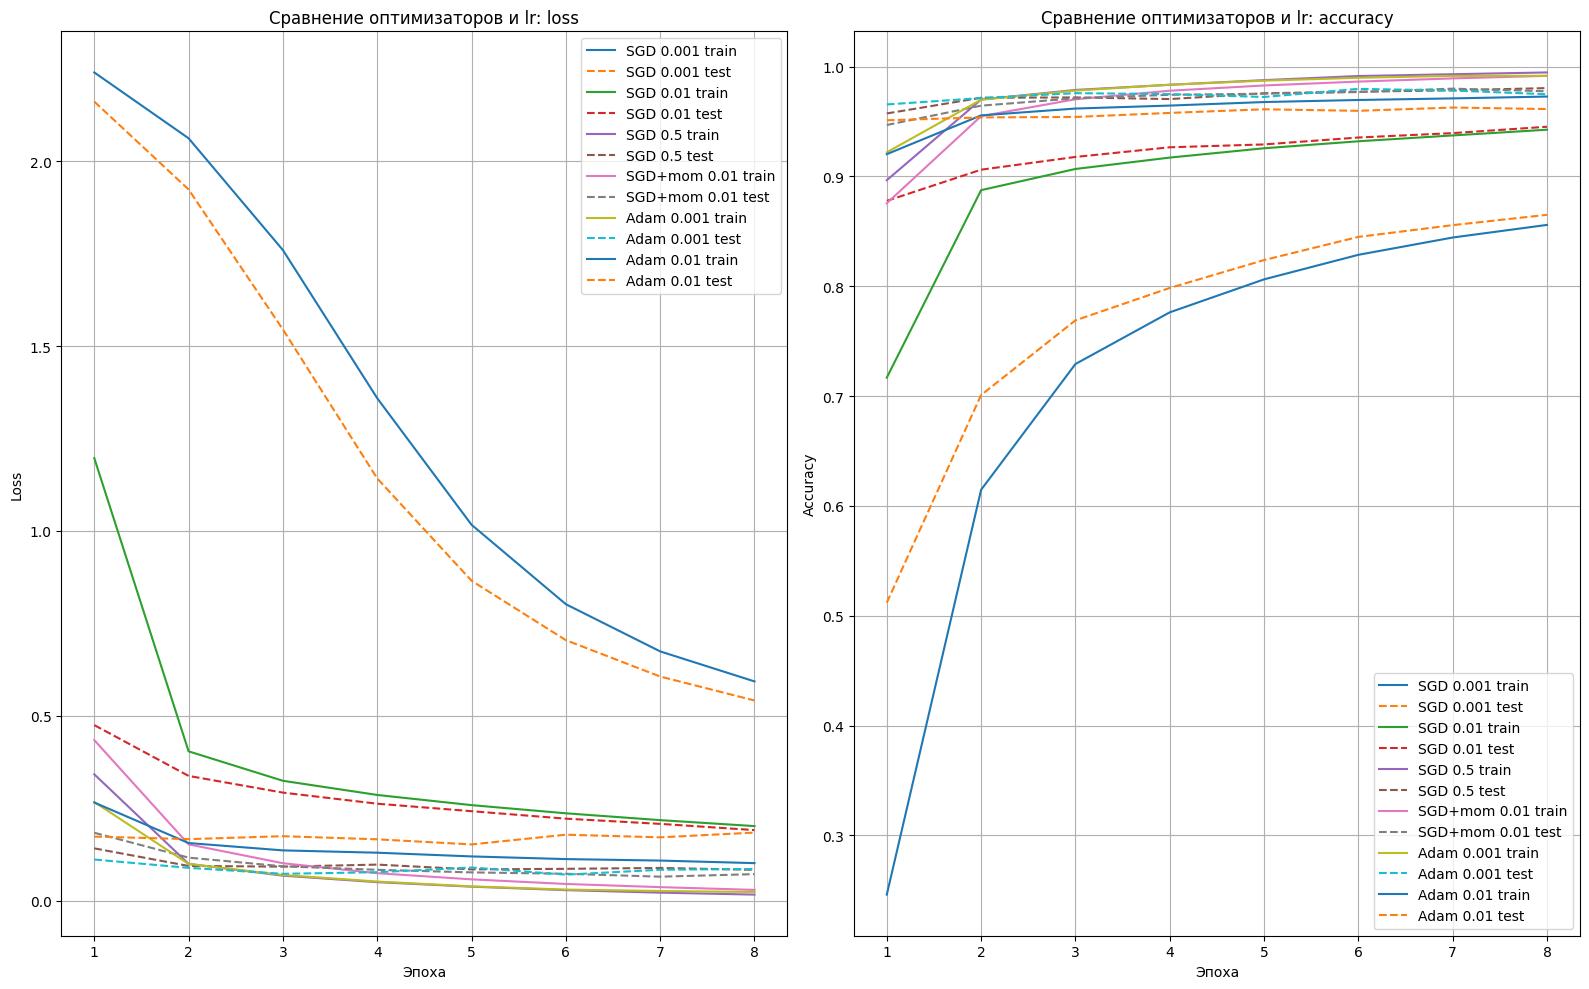

In [34]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(16, 10))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix="Сравнение оптимизаторов и lr: ")

## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Не переписывайте теорию про оптимизаторы — опирайтесь именно на свои графики и числа.

Попробуйте в одном связанном тексте ответить на такие вопросы:

- Как выглядели кривые для `SGD lr=0.001`: насколько медленно росла точность, успела ли она выйти на разумный уровень за `num_epochs`?  
- Что происходило при `SGD lr=0.5`: были ли скачки loss, «разброс» accuracy, признаки расходимости?  
- Как вёл себя `SGD lr=0.01`: показался ли вам этот шаг «рабочим компромиссом» между скоростью и стабильностью?  
- Что дал `momentum`: стало ли обучение более ровным/быстрым, изменилась ли финальная test accuracy по сравнению с чистым SGD?  
- Как отличался `Adam`: быстрее ли он выходил на высокую точность, как вёл себя test loss, было ли переобучение?

Упоминайте конкретные числа (например, test accuracy на последней эпохе для разных конфигураций) и форму кривых (плавные/рывковые, раннее насыщение и т. п.).


In [35]:
analysis_text = """Исходя из графика можно сделать следующие выводы:
SGD lr=0.001 показал медленную сходимость. Точность на тесте росла очень медленно, почти линейно.
    За 8 эпох она не успела выйти даже за 90%.
    Потери плавно снижались, но остались на высоком уровне >50%. 
    Обучение происходило, но очень медленное, необходимо больше эпох.
    
В SGD lr=0.5 произошло резкое обучение. Уже после 2 эпохи были высокие точности и достаточно низкие потери.
Но потом test_loss почти перестал снижаться, а train_loss снижается достаточно хорошо.
К концу 8 эпохи разрыв между train_loss и test_loss достаточно большой, что может говорить о переобучение.
Однако при этом колебаний, скачкой и расходимости нет. КРивые все равно остаются гладкими.

В данном случае SGD lr=0.01 выглядит как рабочий компромисс. 
    test_acc растет стабильно, test_loss стабильно падает без переобучения.
    Нету ни медленно сходимости, ни высокго разрыва(как в случае с SGD lr=0.5) между train_loss и test_loss и train_acc и test_acc.

momentum в оптимизаторе SGD дал заметное ускорение, по сравнению с чистым SGD. УЖе на 1 эпохе разница в test_acc составляет 7%.
    А на 2 эпохе test_acc составляет 97,7%, что выше на 3% по сравнению с 8ой эпохой на SGD lr=0.01, где test_acc=94,5%.
    test_loss снижается до 0.0716 (против 0.1907 у SGD). 
    Обучение стало не только быстрее, но и привело к лучшему итоговому качеству. Кривые плавные, без рывков

Adam lr=0.001 оказался самым быстрым. На 1ой эпохе test_acc=0.9656, что выше, чем у остальных оптимизаторов.
    К 3ей эпохе test_acc уже 97,59%, но дальше заметна небольшая нестабильность. 
    Плавает и test_loss и test_acc. 
    В целом результат хороший, но похоже на небольшое переобучение.

Для Adam lr=0.01 я поставила намеренно высокий шаг, в итоге он показал резульат хуже, чем Adam lr=0.001.
    На 1ой эпохе test_acc = 95,12%, что довольно хороший результат, но потом он почти не растет.(к концу 8ой эпохи вырос на 1%)
    test_loss хаотично прыгает. Оптимизатор не может стабилизироваться.

Подводя итоги, можно сказать, что с данной задачей лучше вспего справился SGD lr=0.5, 
    он быстро и стабильно показал высокий резульат без признаков переобучения.
    Самым быстрым на первых эпохах оказался Adam 0.001.
""" 
print(analysis_text)

Исходя из графика можно сделать следующие выводы:
SGD lr=0.001 показал медленную сходимость. Точность на тесте росла очень медленно, почти линейно.
    За 8 эпох она не успела выйти даже за 90%.
    Потери плавно снижались, но остались на высоком уровне >50%. 
    Обучение происходило, но очень медленное, необходимо больше эпох.

В SGD lr=0.5 произошло резкое обучение. Уже после 2 эпохи были высокие точности и достаточно низкие потери.
Но потом test_loss почти перестал снижаться, а train_loss снижается достаточно хорошо.
К концу 8 эпохи разрыв между train_loss и test_loss достаточно большой, что может говорить о переобучение.
Однако при этом колебаний, скачкой и расходимости нет. КРивые все равно остаются гладкими.

В данном случае SGD lr=0.01 выглядит как рабочий компромисс. 
    test_acc растет стабильно, test_loss стабильно падает без переобучения.
    Нету ни медленно сходимости, ни высокго разрыва(как в случае с SGD lr=0.5) между train_loss и test_loss и train_acc и test_acc.

mom

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме (5–8 предложений), как будто вы объясняете младшим курсам, **что вы вынесли из этой лабораторной**:

- Какие диапазоны `learning_rate` для SGD вы теперь считаете «слишком маленькими», «рабочими» и «слишком агрессивными» — именно на примере этой задачи.  
- В каких случаях вы бы использовали SGD с momentum, а в каких — достаточно обычного SGD.  
- Когда лично вы после этой работы предпочли бы Adam, а когда — всё-таки остались бы на SGD/SGD+Momentum (например, из-за понятности поведения, чувствительности к lr и т.п.).

Важно, чтобы здесь звучал ваш голос и ссылка на ваш опыт, а не абстрактные фразы про «Adam обычно лучше».


In [37]:
final_conclusion = """ 
Я считаю, что для SGD на примере данной задачи слишком маленькими могут быть  0.001 <= lr <= 0.007
    (0.007 приблизительно, так как не считала).
    Рабочими вариантами могут быть lr +- 0.01. lr +- 0.5 могут быть агрессивными.
    
Для подобных задач, я бы использовала SGD с momentum, так как по сравнению с обычным SGD с тем же самым lr(0.01) он заметно укорил обучение,
    поднял точность с 0.9453 до 0.9776 и снизил  потери. 
    Для более простых задач можно было бы использовать просто SGD.

ПОсле этой работы Adam можно было использовать в случае с небольшим количеством эпох, 
    так как видно на примере, что на 2-3 эпохе были уже хорошие результаты.
    Добавленный мною оптимизатор Adam c намеренно высоким шагом = 0.1 показал, что большой шаг - не всегда хорошо, тем более в случае с Adam.

Для данной задачи я бы остановилась на SGD с momentum, однако и Adam при правильно подобранном и оптимальном lr могу бы дать хороший, стабильный разельутат.
Итог такой, лучшего оптимизатора нет, под кажду задачу подходит свой, для начала можно попробовать SGD + momentum и понастравить lr у Adam. 


"""
print(final_conclusion)

 
Я считаю, что для SGD на примере данной задачи слишком маленькими могут быть  0.001 <= lr <= 0.007
    (0.007 приблизительно, так как не считала).
    Рабочими вариантами могут быть lr +- 0.01. lr +- 0.5 могут быть агрессивными.

Для подобных задач, я бы использовала SGD с momentum, так как по сравнению с обычным SGD с тем же самым lr(0.01) он заметно укорил обучение,
    поднял точность с 0.9453 до 0.9776 и снизил  потери. 
    Для более простых задач можно было бы использовать просто SGD.

ПОсле этой работы Adam можно было использовать в случае с небольшим количеством эпох, 
    так как видно на примере, что на 2-3 эпохе были уже хорошие результаты.
    Добавленный мною оптимизатор Adam c намеренно высоким шагом = 0.1 показал, что большой шаг - не всегда хорошо, тем более в случае с Adam.

Для данной задачи я бы остановилась на SGD с momentum, однако и Adam при правильно подобранном и оптимальном lr могу бы дать хороший, стабильный разельутат.
Итог такой, лучшего оптимизатора нет, 